In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os
import glob
import Alvium
import sys
sys.path.append('/home/federico-cacciotti/Documents/src/polocalc_dev/photogrammetry/calibration')
import CameraCalibrationFunctions as ccf
from vmbpy import *
import sounddevice as sd
import time

detector_params = cv2.aruco.DetectorParameters()
#detector_params.cornerRefinementMethod = cv2.aruco.CORNER_REFINE_SUBPIX

In [2]:
def beep(frequency=440, duration=0.5, sample_rate=44100):
    t = np.linspace(0, duration, int(sample_rate * duration))
    wave = 0.5 * np.sin(2 * np.pi * frequency * t)
    sd.play(wave, sample_rate)
    sd.wait()

Camera Intrinsics:
 [[  4.56204380e+03   0.00000000e+00   1.03700000e+03]
 [  0.00000000e+00   4.56204380e+03   7.52000000e+02]
 [  0.00000000e+00   0.00000000e+00   1.00000000e+00]]


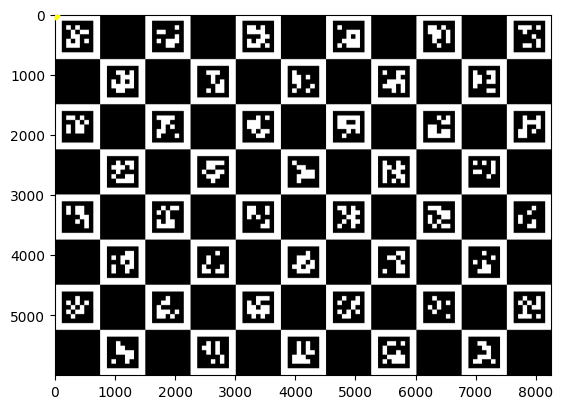

In [3]:
# Camera parameters for Alvium 1800 U-1242c
focal_length = 0.025  # 25mm
pixel_size = 0.00000274  # 2.74 microns
width, height = 4148, 3008 # sensor size in pixels 

# halve the sensor size to simulate a 2x2 binning and speed up the simulations
width //= 2
height //= 2
pixel_size *= 2

# Define ideal intrinsics
fx_ideal = focal_length / pixel_size
fy_ideal = focal_length / pixel_size
cx_ideal = width / 2
cy_ideal = height / 2

K = np.array([[fx_ideal, 0, cx_ideal],
              [0, fy_ideal, cy_ideal],
              [0,  0,  1]], dtype=np.float64)

#dist = np.array([-0.2, 0.05, 0.001, -0.001, 0.01], dtype=np.float64) # k1, k2, p1, p2, k3
dist = np.zeros(5)

print("Camera Intrinsics:\n", K)


# Charuco board parameters
squares_x = 11
squares_y = 8
square_length = 0.108  # meters
pixel_per_square_side = 750

board_width = squares_x * square_length
board_height = squares_y * square_length

# Put the board centered at the origin
board_corners = np.array([
    [-0.5*board_width, -0.5*board_height, 0],
    [0.5*board_width, -0.5*board_height, 0],
    [0.5*board_width, 0.5*board_height, 0],
    [-0.5*board_width, 0.5*board_height, 0]
], dtype=np.float64)


%matplotlib inline

# Create dictionary
dictionary = cv2.aruco.getPredefinedDictionary(
    cv2.aruco.DICT_5X5_100
)

# use sub-pixel refinement
aruco_detector = cv2.aruco.ArucoDetector(dictionary, detector_params)

# Create board object (same geometry as before)
board = cv2.aruco.CharucoBoard(
    (squares_x, squares_y),
    square_length,
    square_length * 0.7,  # marker size
    dictionary
)

# this function defines a board with the first marker in (0,0), not in (1,0), backward compatibility
board.setLegacyPattern(True)

# Get the board points
board_points = board.getChessboardCorners()

# Generate flat board image
board_img = board.generateImage((squares_x*pixel_per_square_side, squares_y*pixel_per_square_side))

plt.figure()
plt.imshow(board_img, cmap='gray', zorder=0)
plt.plot(0, 0, marker='o', color='yellow', zorder=10)
#plt.axis("off")
plt.show()

In [4]:
CAMERA_ID = "DEV_1AB22C0707F3"

EXPOSURE_TIME = 50000  # microseconds
GAIN = 0
IMAGE_WIDTH = 4128
IMAGE_HEIGHT = 3008
PIXEL_SIZE = 0.00000274

camera_bit_depth = 12

In [5]:
cam = Alvium.Camera(CAMERA_ID)

In [ ]:
%matplotlib widget

cam.open()

cam.set_size(IMAGE_WIDTH, IMAGE_HEIGHT)
#cam.set_pixel_format(PixelFormat.Bgr8)
cam.set_pixel_format(PixelFormat.BayerRG12)
cam.configure_raw(EXPOSURE_TIME, GAIN)

frame = cam.get_frame(timeout=3000)
try:
    image = frame.as_opencv_image()
except ValueError:
    image = frame.as_numpy_ndarray()
ccf.show_image(image)

# debayer the image
image_float = image / (2**camera_bit_depth - 1)
color_image = ccf.debayer(image_float, bayer_pattern="RGGB", clip=True)
ccf.show_image(color_image)

# convert to monochrome and quantize to 8 bit of depth, since cv2 works with 8 bit images
grayscale_image = ccf.to_grayscale(color_image)
ccf.show_image(grayscale_image)
grayscale_image_8bit = (grayscale_image * (2**8 - 1)).astype(np.uint8)
ccf.show_image(grayscale_image_8bit)

#ccf.plot_histogram(grayscale_image_8bit, logscale=True)

ccf.measure_frame(grayscale_image_8bit, dictionary, board, show_frame=True)

cam.close()

# live acquisition

In [6]:
%matplotlib tk

cam.open()

cam.set_size(IMAGE_WIDTH, IMAGE_HEIGHT)
#cam.set_pixel_format(PixelFormat.Bgr8)
cam.set_pixel_format(PixelFormat.BayerRG12)
cam.configure_raw(EXPOSURE_TIME, GAIN)

cam.stream_live(grid=True)

cam.close()

Image width set to 4128
Image height set to 3008
Pixel format set to BayerRG12
Exposure time set to 50016.848 microseconds
Gain set to 0.0
White balance set to neutral
Gamma set to 1.0
Sharpness set to 0
Color transformation feature not available


In [ ]:
folder_name = "poses_12mm_f2.4_g0_flat_set2"
continuous_acquisition_poses = 1
wait_time = 0.1 # seconds

In [7]:
%matplotlib inline

if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Folder {folder_name} created")
    image_counter = 0
else:
    print(f"Folder {folder_name} already exists")
    files = glob.glob(os.path.join(folder_name, "*.tiff"))
    image_counter = len(files)
    #raise FileExistsError(f"Folder {folder_name} already exists")

#for i in range(10):
#    beep(frequency=2000, duration=0.05)
#    time.sleep(1)

cam.open()

cam.set_size(IMAGE_WIDTH, IMAGE_HEIGHT)
#cam.set_pixel_format(PixelFormat.Bgr8)
cam.set_pixel_format(PixelFormat.BayerRG12)
cam.configure_raw(EXPOSURE_TIME, GAIN)

for i in range(continuous_acquisition_poses):
    time.sleep(wait_time)

    beep(frequency=2000, duration=0.05)
    beep(frequency=5000, duration=0.05)

    image_counter += 1

    frame = cam.get_frame(timeout=3000)
    try:
        image = frame.as_opencv_image()
    except ValueError:
        image = frame.as_numpy_ndarray()

    ccf.show_image(image)
    filename = "{:03d}.tiff".format(image_counter)
    cv2.imwrite(os.path.join(folder_name, filename), image)

    beep(frequency=4000, duration=0.05)

cam.close()

beep(frequency=5000, duration=0.05)
beep(frequency=5000, duration=0.05)
beep(frequency=5000, duration=0.05)

NameError: name 'folder_name' is not defined